In [1]:
import sys
from pathlib import Path

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

In [27]:
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import *
import numpy as np

In [4]:
from data.test_data.HanSeg_to_npz import CTProcessor, MRIProcessor

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def visualize_img_with_mask(mri, mask, alpha=0.5):
    assert mri.shape == mask.shape

    depth = mri.shape[0]

    def show_slice(idx):
        plt.figure(figsize=(6,6))
        plt.imshow(mri[idx], cmap='gray')
        plt.imshow(mask[idx], cmap='jet', alpha=alpha)
        plt.title(f"Slice {idx}")
        plt.axis('off')
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=depth-1,
        step=1,
        description='Slice:'
    )

    widgets.interact(show_slice, idx=slider)

# CT

In [6]:
# CT pipeline
proc = CTProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("HanSeg_CT")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  -> Success: shape (139, 668, 943)

[2/4] Processing case_18 ...
  -> Success: shape (121, 720, 928)

[3/4] Processing case_25 ...
  -> Success: shape (147, 621, 838)

[4/4] Processing case_40 ...
  -> Success: shape (155, 687, 961)

Saving dataset to HanSeg_CT.npz ...
Save complete!

OAR Mapping: {'A_Carotid_L': 1, 'A_Carotid_R': 2, 'Arytenoid': 3, 'Bone_Mandible': 4, 'Brainstem': 5, 'BuccalMucosa': 6, 'Cavity_Oral': 7, 'Cochlea_L': 8, 'Cochlea_R': 9, 'Cricopharyngeus': 10, 'Esophagus_S': 11, 'Eye_AL': 12, 'Eye_AR': 13, 'Eye_PL': 14, 'Eye_PR': 15, 'Glnd_Lacrimal_L': 16, 'Glnd_Lacrimal_R': 17, 'Glnd_Submand_L': 18, 'Glnd_Submand_R': 19, 'Glnd_Thyroid': 20, 'Glottis': 21, 'Larynx_SG': 22, 'Lips': 23, 'OpticChiasm': 24, 'OpticNrv_L': 25, 'OpticNrv_R': 26, 'Parotid_L': 27, 'Parotid_R': 28, 'Pituitary': 29, 'SpinalCord': 30}


In [10]:
dg_ct = DataGenerator(DataLoader_npz(["data/test_data/HanSeg_CT.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HanSeg_CT.npz

Final dataset size: 4 patients.



In [11]:
print(dg_ct.dataloader.train_ids)
print(dg_ct.dataloader.validation_ids)

['HanSeg_CT_case_18', 'HanSeg_CT_case_25', 'HanSeg_CT_case_04', 'HanSeg_CT_case_40']
[]


In [12]:
img_ct = dg_ct.dataloader.dataset['HanSeg_CT_case_04']['image']
segmentations_ct = dg_ct.dataloader.dataset['HanSeg_CT_case_04']['segmentations']

In [13]:
print(segmentations_ct[0].shape)
print(img_ct.shape)

(139, 668, 943)
(139, 668, 943)


In [ ]:
visualize_img_with_mask(img_ct, segmentations_ct[0])

interactive(children=(IntSlider(value=0, description='Slice:', max=138), Output()), _dom_classes=('widget-inte…

In [20]:
# ds, offset_list = dg_ct.get_data_points(max_data_points=100, offset=10, max_number_labels=3, cropping=True, min_crop_size=0.4)
ds, offset_list = dg_ct.get_data_points(max_data_points=100, offset=10, max_number_labels=3, cropping=False)

Creating new Data Points ...
It took 7 seconds


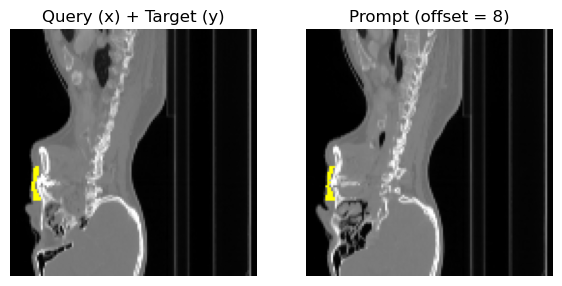


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


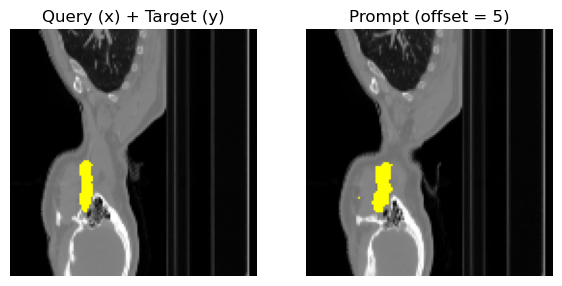


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


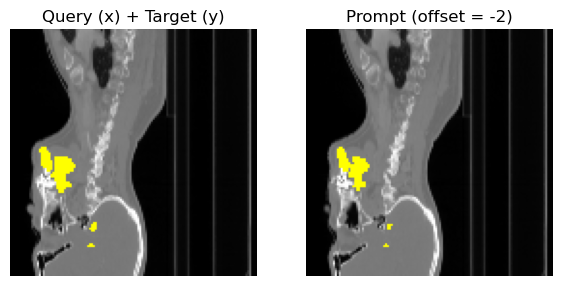


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


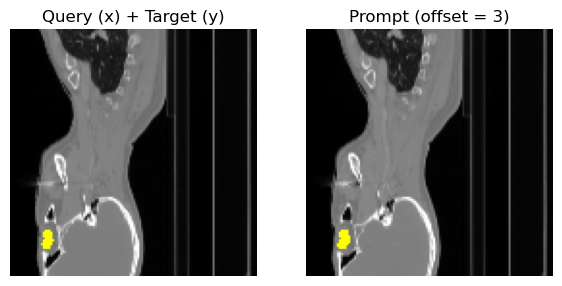


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


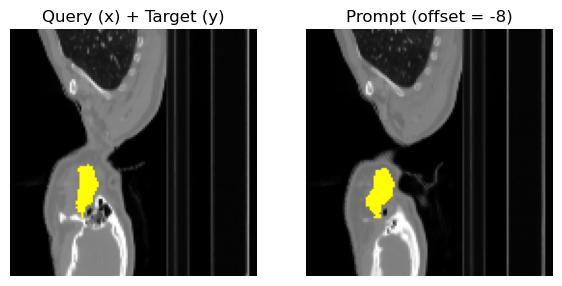


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


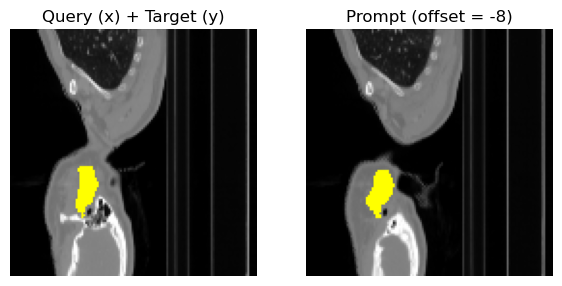


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


In [28]:
for counter,(x,y,p) in enumerate(ds):
    plot_one_dp(x,y,p, offset_list[counter])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if counter == 5:
        break

# MRI

In [29]:
# MRI pipeline
proc = MRIProcessor("HanSeg/set_1", oar_csv_path="HanSeg/set_1/OAR_data.csv")
proc.process_dataset("HanSeg_MRI")

Loading OAR availability from HanSeg/set_1/OAR_data.csv

[1/4] Processing case_04 ...
  Registration OK  (metric = -0.5171)
  -> Success: shape (87, 433, 425)

[2/4] Processing case_18 ...
  Registration OK  (metric = -0.5891)
  -> Success: shape (71, 444, 436)

[3/4] Processing case_25 ...
  Registration OK  (metric = -0.7015)
  -> Success: shape (116, 383, 378)

[4/4] Processing case_40 ...
  Registration OK  (metric = -0.6517)
  -> Success: shape (105, 444, 439)

Saving dataset to HanSeg_MRI.npz ...
Save complete!

OAR Mapping: {'A_Carotid_L': 1, 'A_Carotid_R': 2, 'Arytenoid': 3, 'Bone_Mandible': 4, 'Brainstem': 5, 'BuccalMucosa': 6, 'Cavity_Oral': 7, 'Cochlea_L': 8, 'Cochlea_R': 9, 'Cricopharyngeus': 10, 'Esophagus_S': 11, 'Eye_AL': 12, 'Eye_AR': 13, 'Eye_PL': 14, 'Eye_PR': 15, 'Glnd_Lacrimal_L': 16, 'Glnd_Lacrimal_R': 17, 'Glnd_Submand_L': 18, 'Glnd_Submand_R': 19, 'Glnd_Thyroid': 20, 'Glottis': 21, 'Larynx_SG': 22, 'Lips': 23, 'OpticChiasm': 24, 'OpticNrv_L': 25, 'OpticNrv_R': 26

In [32]:
dg_mr = DataGenerator(DataLoader_npz(["data/test_data/HanSeg_MRI.npz"], val_size=0.0))


Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HanSeg_MRI.npz

Final dataset size: 4 patients.



In [33]:
img_mr = dg_mr.dataloader.dataset['HanSeg_MRI_case_04']['image']
segmentations_mr = dg_mr.dataloader.dataset['HanSeg_MRI_case_04']['segmentations']

In [34]:
print(segmentations_mr[0].shape)
print(img_mr.shape)

(87, 433, 425)
(87, 433, 425)


In [ ]:
visualize_img_with_mask(img_mr, segmentations_mr[0])

interactive(children=(IntSlider(value=0, description='Slice:', max=86), Output()), _dom_classes=('widget-inter…

In [36]:
# ds, offset_list = dg_mr.get_data_points(max_data_points=100, offset=10, max_number_labels=3, cropping=True, min_crop_size=0.4)
ds, offset_list = dg_mr.get_data_points(max_data_points=10, offset=10, max_number_labels=3, cropping=False)

Creating new Data Points ...
It took 0 seconds


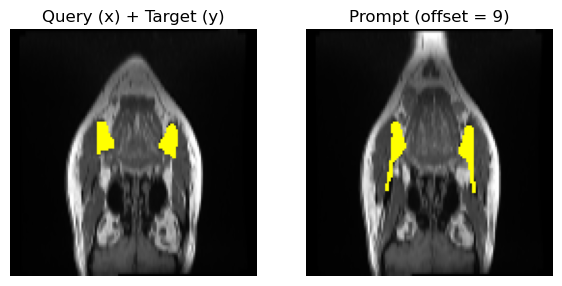


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


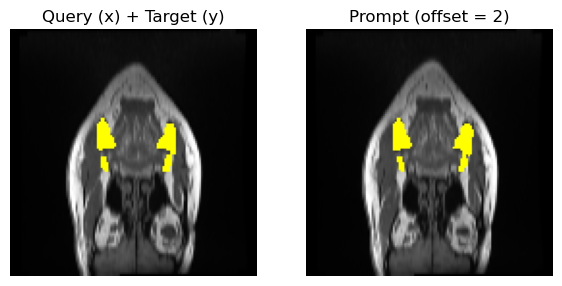


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


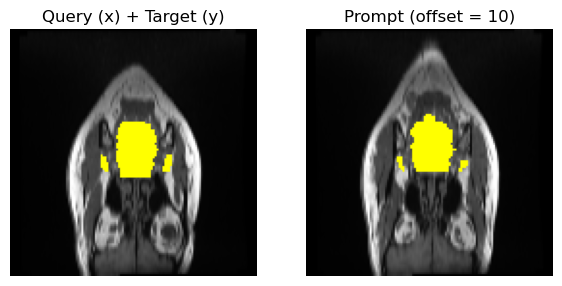


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


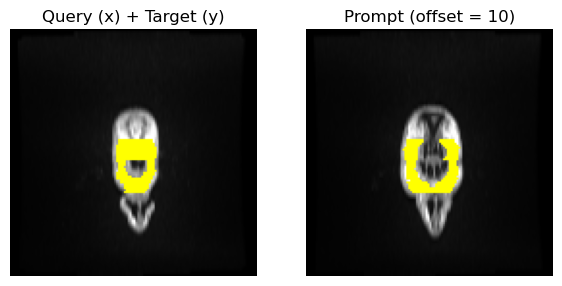


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


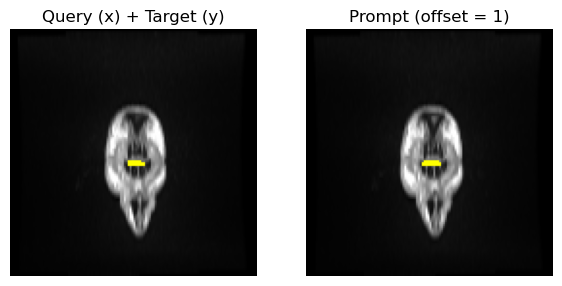


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


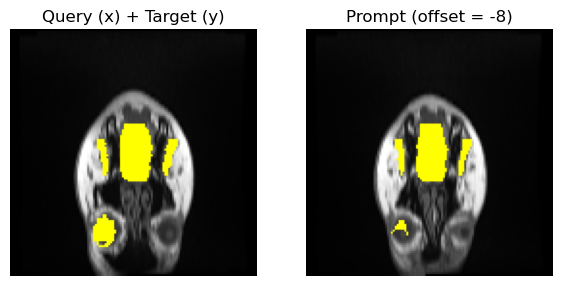


x: 0.0 - 1.0 | y: 0.0 - 1.0 | p (img): 0.0 - 1.0 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
<dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'> <dtype: 'float32'>


In [37]:
for counter,(x,y,p) in enumerate(ds):
    plot_one_dp(x,y,p, offset_list[counter])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if counter == 5:
        break